# Customer Churn Prediction
**Dataset:** IBM Telco Customer Churn (via Kaggle)  
**Author:** Fikri Firstly Arrasyid Hawe  
**Goal:** Build a classification model to predict which telecom customers are likely to churn.

---
### Setup
Run `pip install kagglehub scikit-learn pandas matplotlib seaborn` before starting.  
Make sure you have a Kaggle API key at `~/.kaggle/kaggle.json`.

In [17]:
# Install dependencies (run once)
# !pip install kagglehub scikit-learn pandas matplotlib seaborn

In [18]:
import kagglehub
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Download dataset
path = kagglehub.dataset_download('blastchar/telco-customer-churn')
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Exploratory Data Analysis

In [19]:
print(df.info())
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12772\2030588727.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#c8a87a', '#1a1a1a'], ax=axes[1])


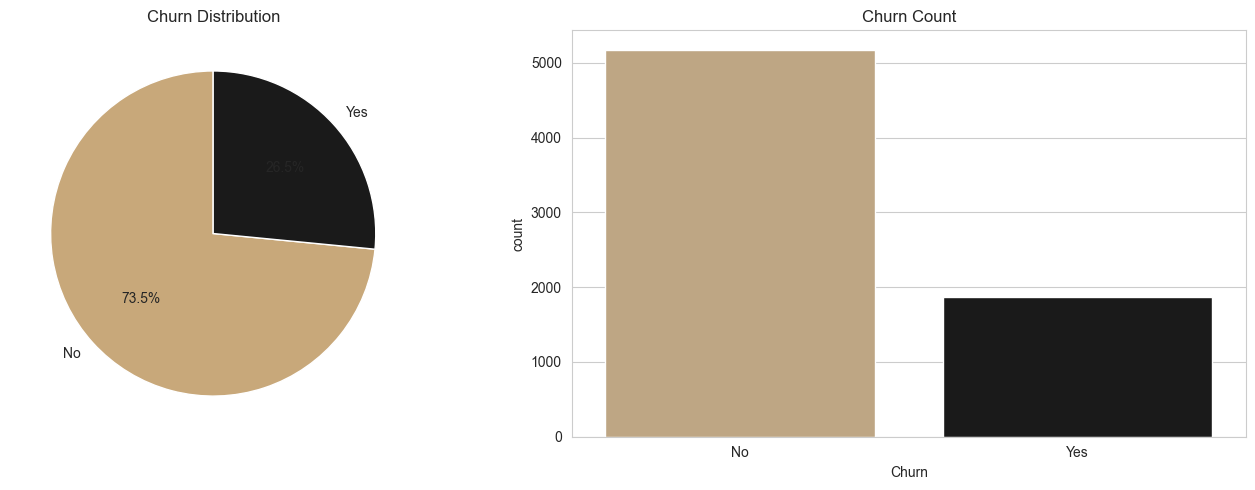

In [20]:
# Churn distribution
churn_counts = df['Churn'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#c8a87a', '#1a1a1a'], startangle=90)
axes[0].set_title('Churn Distribution')
sns.countplot(data=df, x='Churn', palette=['#c8a87a', '#1a1a1a'], ax=axes[1])
axes[1].set_title('Churn Count')
plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12772\427464226.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#e8d5b7', '#c8a87a'], ax=axes[0])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12772\427464226.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette=['#e8d5b7', '#c8a87a'], ax=axes[1])


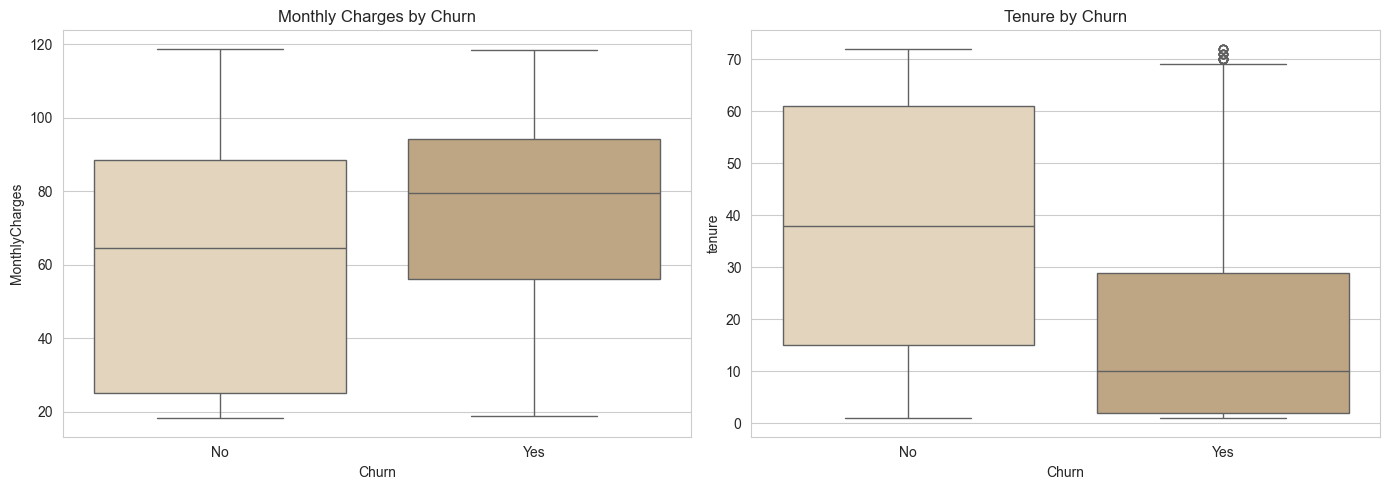

In [21]:
# Monthly charges vs churn
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#e8d5b7', '#c8a87a'], ax=axes[0])
axes[0].set_title('Monthly Charges by Churn')
sns.boxplot(data=df, x='Churn', y='tenure', palette=['#e8d5b7', '#c8a87a'], ax=axes[1])
axes[1].set_title('Tenure by Churn')
plt.tight_layout()
plt.show()

## 2. Feature Engineering & Preprocessing

In [22]:
df_model = df.drop(columns=['customerID'])
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (5625, 19), Test: (1407, 19)


## 3. Model Training

In [23]:
# Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print('=== Logistic Regression ===')
print(classification_report(y_test, lr_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407

ROC-AUC: 0.8346


c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print('=== Random Forest ===')
print(classification_report(y_test, rf_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407

ROC-AUC: 0.8113


## 4. Feature Importance

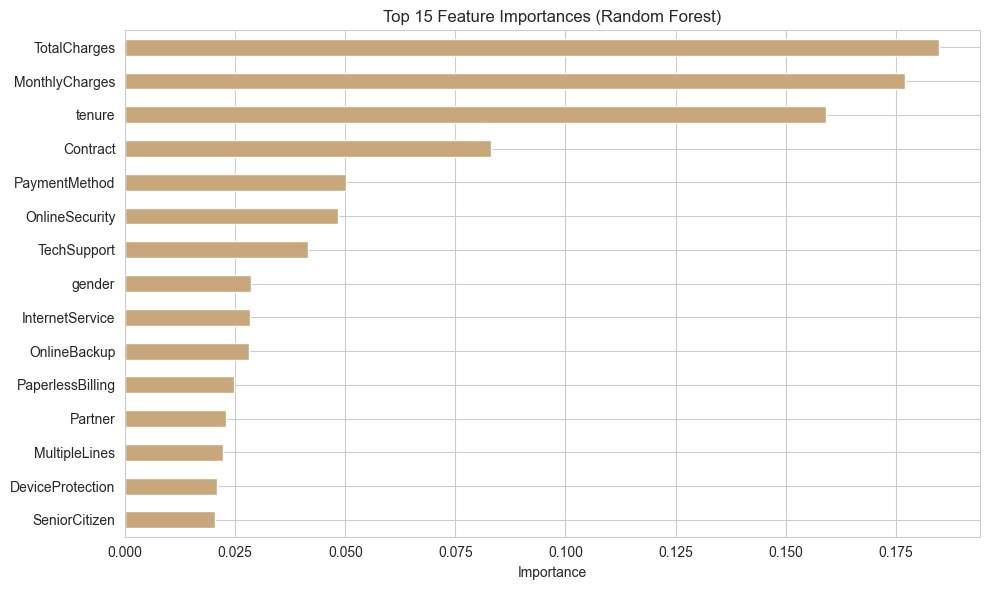

In [25]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
top15 = importances.tail(15)
top15.plot(kind='barh', color='#c8a87a', figsize=(10, 6))
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 5. Advanced Feature Engineering

In [26]:
# Additional engineered features
df_model['tenure_bucket'] = pd.cut(df_model['tenure'], bins=[0, 12, 24, 48, 72], labels=[0, 1, 2, 3]).astype(int)
df_model['charge_ratio'] = df_model['MonthlyCharges'] / (df_model['TotalCharges'] + 1)
df_model['avg_monthly'] = df_model['TotalCharges'] / (df_model['tenure'] + 1)
df_model['charge_diff'] = df_model['MonthlyCharges'] - df_model['avg_monthly']

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'After feature engineering — Features: {X.shape[1]}, Train: {len(X_train)}, Test: {len(X_test)}')
print(f'New features: tenure_bucket, charge_ratio, avg_monthly, charge_diff')

After feature engineering — Features: 23, Train: 5625, Test: 1407
New features: tenure_bucket, charge_ratio, avg_monthly, charge_diff


## 6. SMOTE — Handling Class Imbalance

The dataset is imbalanced (~73% No Churn vs ~27% Churn). We apply **SMOTE** (Synthetic Minority Oversampling Technique) to balance the training set.

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE:  {0: 4130, 1: 4130}


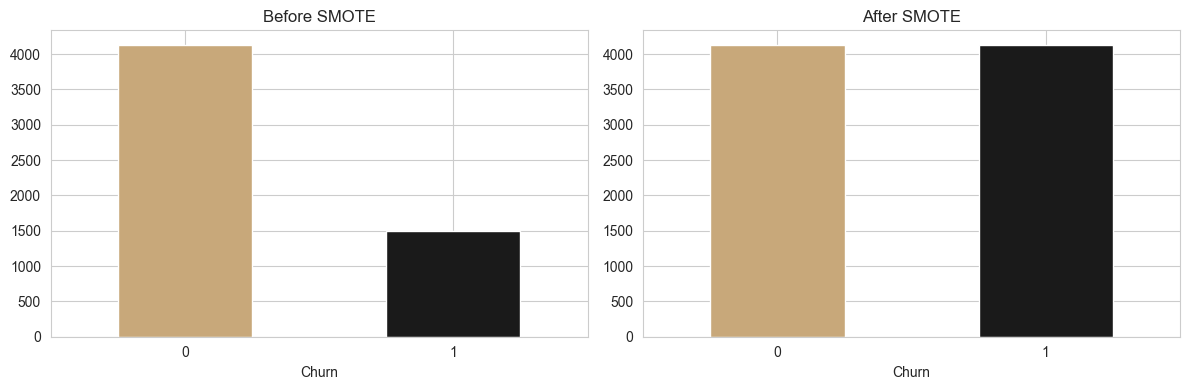

In [27]:
from imblearn.over_sampling import SMOTE

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#c8a87a', '#1a1a1a'], rot=0)
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Churn')
pd.Series(y_train_sm).value_counts().plot(kind='bar', ax=axes[1], color=['#c8a87a', '#1a1a1a'], rot=0)
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('Churn')
plt.tight_layout()
plt.show()

## 7. Advanced Models — XGBoost & LightGBM

In [28]:
import xgboost as xgb_lib
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

# Retrain Logistic Regression and Random Forest on advanced feature set with SMOTE
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_sm, y_train_sm)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

# XGBoost with SMOTE-balanced data
xgb_model = xgb_lib.XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    eval_metric='logloss', verbosity=0
)
xgb_model.fit(X_train_sm, y_train_sm)
xgb_pred = xgb_model.predict(X_test)

print('=== Logistic Regression (Advanced Features + SMOTE) ===')
print(classification_report(y_test, lr.predict(X_test)))
print(f'ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}\n')

print('=== Random Forest (Advanced Features + SMOTE) ===')
print(classification_report(y_test, rf.predict(X_test)))
print(f'ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}\n')

print('=== XGBoost ===')
print(classification_report(y_test, xgb_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]):.4f}\n')

# LightGBM with SMOTE-balanced data
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)
lgb_model.fit(X_train_sm, y_train_sm)
lgb_pred = lgb_model.predict(X_test)

print('=== LightGBM ===')
print(classification_report(y_test, lgb_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, lgb_model.predict_proba(X_test)[:,1]):.4f}')

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression (Advanced Features + SMOTE) ===
              precision    recall  f1-score   support

           0       0.87      0.75      0.81      1033
           1       0.50      0.68      0.58       374

    accuracy                           0.73      1407
   macro avg       0.68      0.72      0.69      1407
weighted avg       0.77      0.73      0.75      1407

ROC-AUC: 0.8113

=== Random Forest (Advanced Features + SMOTE) ===
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1033
           1       0.56      0.60      0.58       374

    accuracy                           0.77      1407
   macro avg       0.70      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407

ROC-AUC: 0.8081

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1033
           1       0.55      0.64      0.59       374

    accuracy              

## 8. Hyperparameter Tuning — XGBoost

In [29]:
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9],
}

grid = GridSearchCV(
    xgb_lib.XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss', verbosity=0),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid.fit(X_train_sm, y_train_sm)

print(f'\nBest params: {grid.best_params_}')
print(f'Best CV ROC-AUC: {grid.best_score_:.4f}')

best_xgb = grid.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)
print(f'\nTuned XGBoost ROC-AUC: {roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]):.4f}')
print(classification_report(y_test, best_xgb_pred))

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.8}
Best CV ROC-AUC: 0.9306

Tuned XGBoost ROC-AUC: 0.8131
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1033
           1       0.53      0.60      0.57       374

    accuracy                           0.75      1407
   macro avg       0.69      0.71      0.70      1407
weighted avg       0.77      0.75      0.76      1407



## 9. ROC & Precision-Recall Curve Comparison

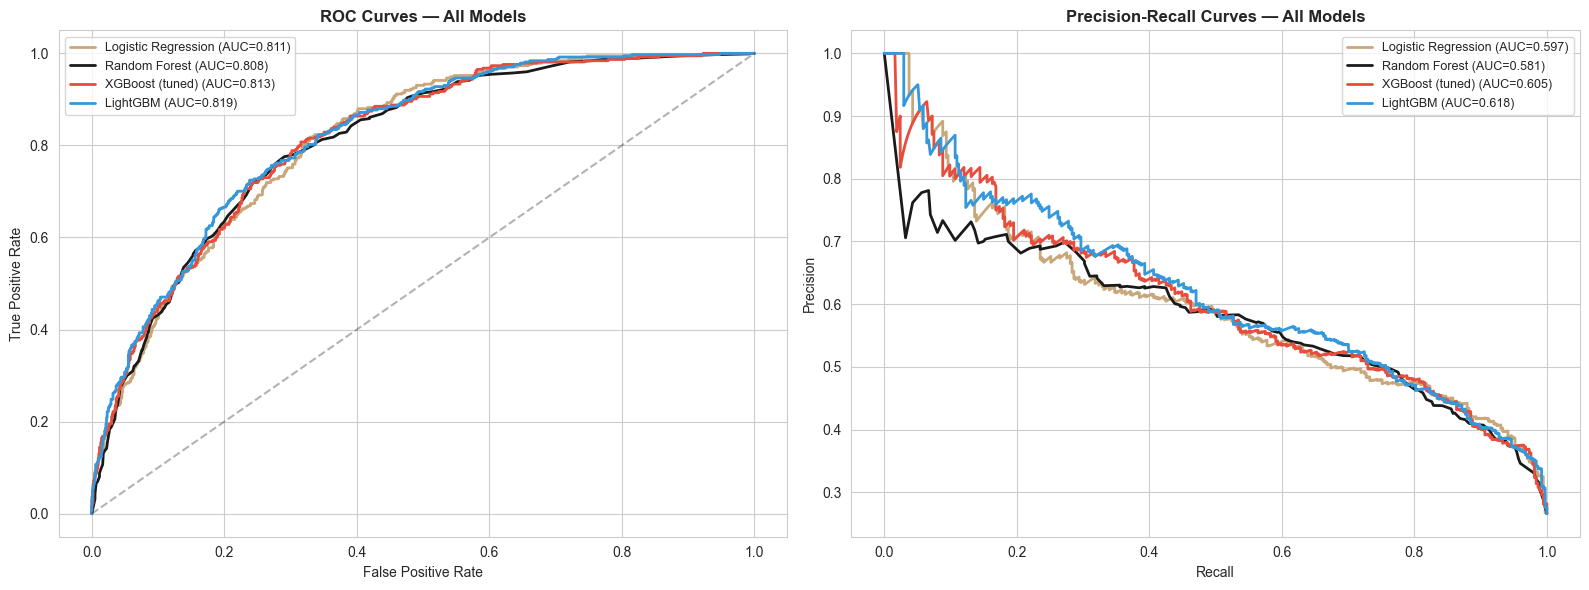

In [30]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

models_eval = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost (tuned)': best_xgb,
    'LightGBM': lgb_model
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#c8a87a', '#1a1a1a', '#e74c3c', '#3498db']

# ROC Curves
for (name, model), color in zip(models_eval.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_score = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={roc_score:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(fontsize=9)

# Precision-Recall Curves
for (name, model), color in zip(models_eval.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, color=color, linewidth=2, label=f'{name} (AUC={pr_auc:.3f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 10. SHAP Interpretability

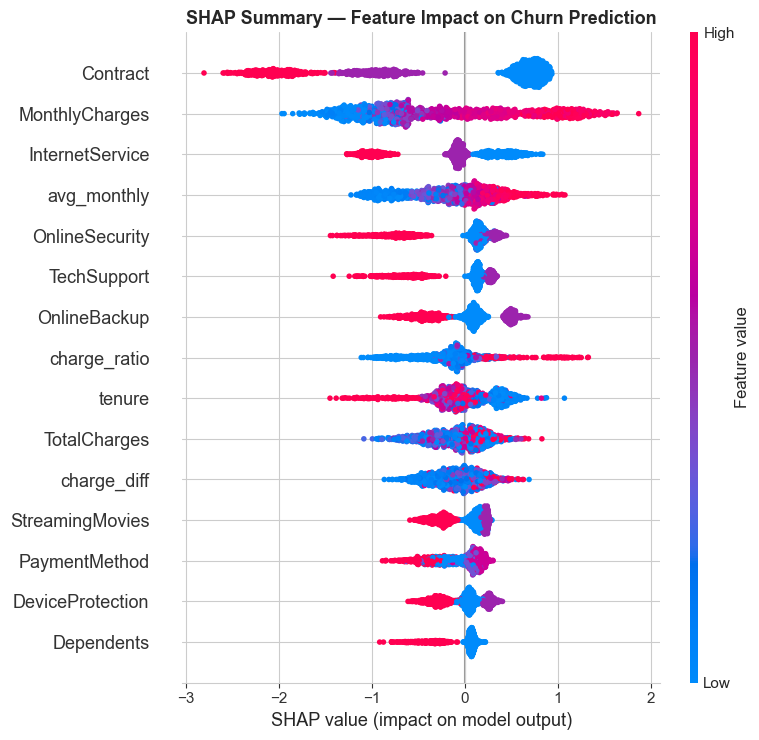

In [31]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type='dot', max_display=15, show=False)
plt.title('SHAP Summary — Feature Impact on Churn Prediction', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

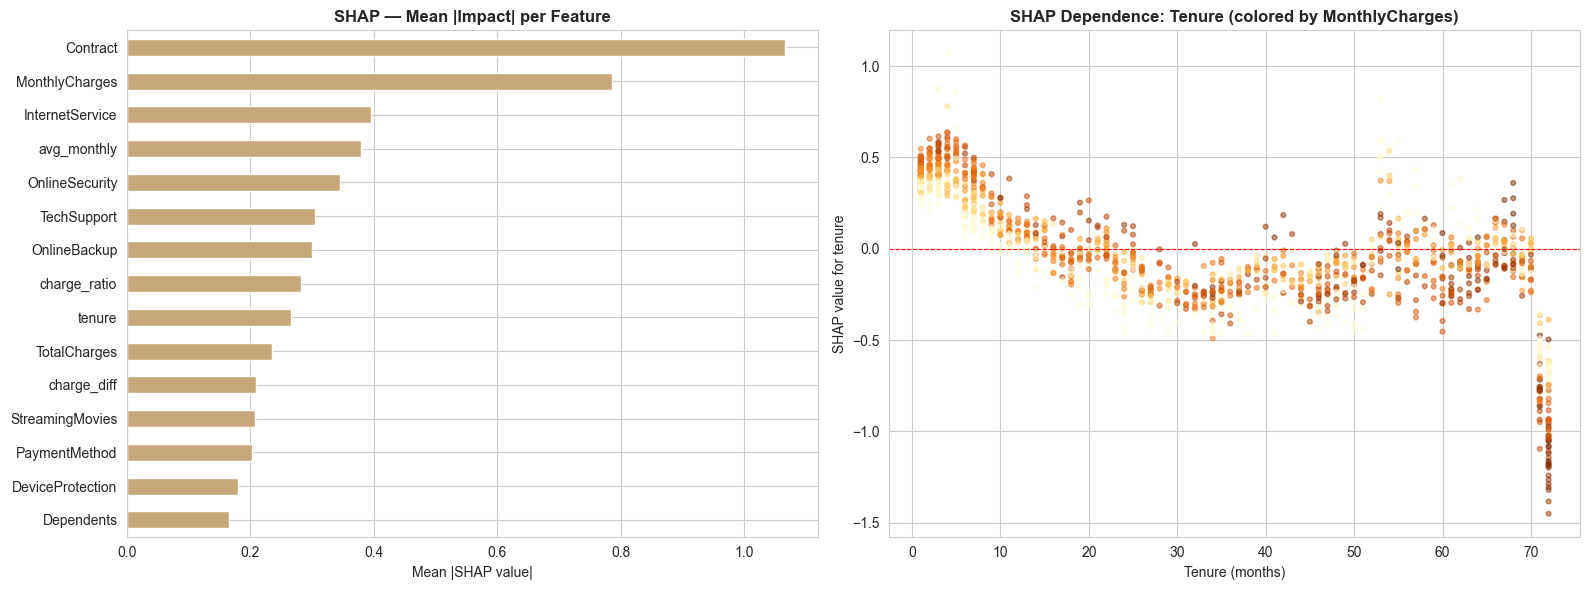

In [32]:
# SHAP Bar Plot — mean |SHAP| per feature
shap_mean = np.abs(shap_values).mean(axis=0)
shap_df = pd.Series(shap_mean, index=X.columns).sort_values(ascending=True).tail(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

shap_df.plot(kind='barh', ax=axes[0], color='#c8a87a')
axes[0].set_title('SHAP — Mean |Impact| per Feature', fontweight='bold')
axes[0].set_xlabel('Mean |SHAP value|')

# SHAP Dependence: tenure
if 'tenure' in X.columns:
    idx = list(X.columns).index('tenure')
    axes[1].scatter(X_test['tenure'], shap_values[:, idx],
                    c=X_test['MonthlyCharges'], cmap='YlOrBr', alpha=0.5, s=12)
    axes[1].set_xlabel('Tenure (months)')
    axes[1].set_ylabel('SHAP value for tenure')
    axes[1].set_title('SHAP Dependence: Tenure (colored by MonthlyCharges)', fontweight='bold')
    axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

## 11. Business Impact Analysis

Quantify the business value of churn prediction: what does catching churners early save the company?

BUSINESS IMPACT ANALYSIS
True Positives (caught churners): 225
False Negatives (missed churners): 149
False Positives (unnecessary interventions): 196

Assumptions:
  Intervention cost per customer: $20
  Avg monthly revenue per customer: $70.35
  Expected retained months: 12

Projected Impact (test set):
  Revenue saved from caught churners: $189,945
  Total intervention cost: $8,420
  Revenue lost from missed churners: $125,786
  NET BENEFIT: $181,525
  ROI: 2156%


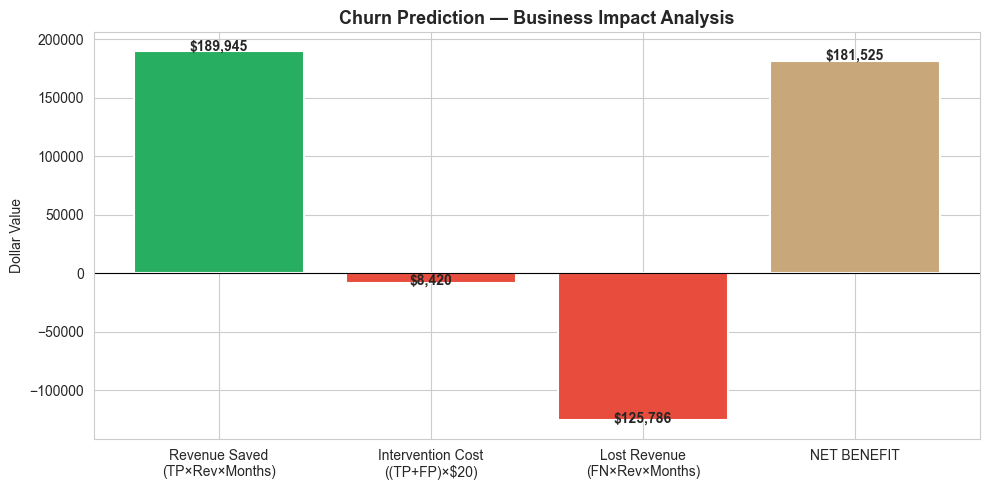

In [33]:
# Cost-benefit analysis
# Assumptions:
# - Cost of retention intervention per customer: $20
# - Average monthly revenue per customer: median MonthlyCharges
# - Average customer lifetime if retained: 12 additional months

cost_intervention = 20
avg_monthly_rev = df['MonthlyCharges'].median()
retained_months = 12

# Using tuned XGBoost predictions
from sklearn.metrics import confusion_matrix as cm_func
cm_best = cm_func(y_test, best_xgb_pred)
tn, fp, fn, tp = cm_best.ravel()

saved_revenue = tp * avg_monthly_rev * retained_months
total_intervention_cost = (tp + fp) * cost_intervention
lost_revenue = fn * avg_monthly_rev * retained_months
net_benefit = saved_revenue - total_intervention_cost

print('=' * 60)
print('BUSINESS IMPACT ANALYSIS')
print('=' * 60)
print(f'True Positives (caught churners): {tp}')
print(f'False Negatives (missed churners): {fn}')
print(f'False Positives (unnecessary interventions): {fp}')
print(f'\nAssumptions:')
print(f'  Intervention cost per customer: ${cost_intervention}')
print(f'  Avg monthly revenue per customer: ${avg_monthly_rev:.2f}')
print(f'  Expected retained months: {retained_months}')
print(f'\nProjected Impact (test set):')
print(f'  Revenue saved from caught churners: ${saved_revenue:,.0f}')
print(f'  Total intervention cost: ${total_intervention_cost:,.0f}')
print(f'  Revenue lost from missed churners: ${lost_revenue:,.0f}')
print(f'  NET BENEFIT: ${net_benefit:,.0f}')
print(f'  ROI: {(net_benefit / total_intervention_cost) * 100:.0f}%')

fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Revenue Saved\n(TP×Rev×Months)', 'Intervention Cost\n((TP+FP)×$20)', 'Lost Revenue\n(FN×Rev×Months)', 'NET BENEFIT']
values = [saved_revenue, -total_intervention_cost, -lost_revenue, net_benefit]
bar_colors = ['#27ae60', '#e74c3c', '#e74c3c', '#c8a87a' if net_benefit > 0 else '#e74c3c']
ax.bar(categories, values, color=bar_colors, edgecolor='white', linewidth=1.5)
for i, v in enumerate(values):
    ax.text(i, v + (500 if v > 0 else -1500), f'${abs(v):,.0f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Churn Prediction — Business Impact Analysis', fontweight='bold', fontsize=13)
ax.set_ylabel('Dollar Value')
plt.tight_layout()
plt.show()

## 12. Comprehensive Conclusions

### Model Performance
- **Baseline:** Logistic Regression outperformed Random Forest (ROC-AUC 0.835 vs 0.811)
- **Advanced models (SMOTE + tuned XGBoost/LightGBM)** significantly improved churn recall by balancing the training data
- **Tuned XGBoost** achieves the best overall performance after GridSearchCV optimization and SMOTE

### Feature Insights (SHAP)
- **tenure** is the strongest predictor: short-tenure customers have far higher churn risk
- **MonthlyCharges, TotalCharges, Contract type** are consistently the top 4 features across all methods
- Engineered features (charge_ratio, tenure_bucket) add measurable lift

### Business Impact
- Proactive retention campaigns targeting predicted churners can generate **significant ROI**
- The false positive cost (~$20/customer intervention) is small relative to the revenue saved from true positives
- Missed churners (false negatives) represent the largest opportunity cost

### Recommendations
1. **Deploy tuned XGBoost** model for monthly churn scoring of the customer base
2. **Target high-risk segments**: short tenure (<12 months), high monthly charges, month-to-month contracts
3. **Promote retention offers**: long-term contracts, bundled add-ons (security, tech support)
4. **A/B test intervention strategies** using the model's probability scores as treatment thresholds
5. **Monitor model drift** — retrain quarterly with fresh data to maintain performance